# 12 — Mehanizam i lijek: projekcijski QP overlay (HRP/HERC/NCO)

Faza 4: **F4.2** (overlay walk-forward s ε-preletom, 2×2 faktorijal) i **F4.3**
(euklidska norma kao robusnost).

Overlay ne rješava alokatore iznova: na **zamrznute** težine iz Faze 1
(korelacijski prostor, `09_weights_panel_hierarchical.csv`) i Faze 3
(faktorski prostor, `11_weights_panel_factor.csv`) primjenjuje projekcijski QP
`project_factor_neutral` (F4.1) — minimalnu izmjenu težina koja zadovoljava
`|w'β_f| ≤ ε` za četiri FF5 stilska faktora. Σ se po prozoru ponovno procjenjuje
istim Ledoit–Wolf procjeniteljem na univerzumu baznog portfelja (identična onoj
iz izvornog runnera); bete su iz `factor_exposures.csv` **istog prozora** (bez
gledanja unaprijed).

Korelacijska baza za HRP overlay je **`hrp_corr_ward`** (krak kontrolirane
usporedbe, K1); `hrp_corr_single` (jednostruka veza) ne dobiva overlay. ε-mreža
`[0, 0.05, 0.10, 0.15]` → 3 alokatora × 2 prostora × 4 ε = **24 overlay
varijante**. Σ-norma (minimalni tracking error) je primarna; euklidska norma je
robusnost (F4.3). DSR, granica stil–vol i finalni MCS su F4.4–F4.6.

In [1]:
%load_ext autoreload
%autoreload 2

import logging
import sys
from pathlib import Path

import numpy as np
import pandas as pd

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

logging.basicConfig(level=logging.WARNING, format="%(asctime)s %(levelname)s %(message)s")

from src.backtest import (
    OVERLAY_BASE_PORTFOLIOS,
    generate_rolling_windows,
    run_overlay_sweep,
)
from src.evaluation import (
    annualized_vol,
    apply_costs,
    max_drawdown,
    sharpe_ratio,
    style_concentration,
    turnover_per_window,
)
from src.utils import (
    EPSILON_GRID,
    PROCESSED_DATA_DIR,
    TABLES_DIR,
    TC_BPS,
    W_MAX,
    ensure_dirs,
    set_seed,
)

ensure_dirs()
set_seed()

In [2]:
monthly_returns = pd.read_csv(
    PROCESSED_DATA_DIR / "monthly_returns.csv", index_col=0, parse_dates=True
)
factor_exposures = pd.read_csv(PROCESSED_DATA_DIR / "factor_exposures.csv")
factors = pd.read_csv(
    PROCESSED_DATA_DIR / "factors.csv", index_col=0, parse_dates=True
)

# Zamrznuti paneli težina: korelacijski (Faza 1) + faktorski (Faza 3).
corr_weights = pd.read_csv(TABLES_DIR / "09_weights_panel_hierarchical.csv")
factor_weights = pd.read_csv(TABLES_DIR / "11_weights_panel_factor.csv")
base_weights_panel = pd.concat([corr_weights, factor_weights], ignore_index=True)

windows = generate_rolling_windows()
epsilons = tuple(EPSILON_GRID)
rf = factors["RF"]

print("Prozori:", len(windows), "|", windows[0].label, "->", windows[-1].label)
print("ε-mreža:", epsilons, "| w_max:", W_MAX, "| tc_bps:", TC_BPS)
print("Bazni portfelji (bez hrp_corr_single):", [b[0] for b in OVERLAY_BASE_PORTFOLIOS])

Prozori: 13 | 2012-12 -> 2024-12
ε-mreža: (0.0, 0.05, 0.1, 0.15) | w_max: 0.05 | tc_bps: 10
Bazni portfelji (bez hrp_corr_single): ['hrp_corr_ward', 'herc_corr', 'nco_corr', 'hrp_factor', 'herc_factor', 'nco_factor']


## 12.1 F4.2 — Overlay walk-forward s ε-preletom (2×2 faktorijal)

`run_overlay_sweep(norm="sigma")` po prozoru rekonstruira Σ na univerzumu svake
baze i projicira njezine težine na `|w'β_f| ≤ ε` za svaki ε. Σ-norma je
primarna (minimalni tracking error prema hijerarhijskom portfelju). Neizvedivi
prozori (tipično ε=0 u ranim prozorima) bilježe se u status log i ne prekidaju
pokretanje.

In [3]:
overlay_sigma = run_overlay_sweep(
    base_weights_panel,
    monthly_returns,
    factor_exposures,
    windows,
    epsilons=epsilons,
    norm="sigma",
)
overlay_returns = overlay_sigma["port_returns_panel"]
overlay_weights = overlay_sigma["weights_panel"]
overlay_status = overlay_sigma["portfolio_status"]

overlay_returns.to_csv(TABLES_DIR / "12_port_returns_panel_overlay.csv")
overlay_weights.to_csv(TABLES_DIR / "12_weights_panel_overlay.csv", index=False)
overlay_status.to_csv(TABLES_DIR / "12_overlay_status.csv", index=False)

print("Overlay panel prinosa (Σ-norma):", overlay_returns.shape)
print("Varijante:", list(overlay_returns.columns))
print("\nStatus po ishodu:")
print(overlay_status["status"].value_counts())
infeasible = overlay_status.loc[~overlay_status["status"].eq("ok")]
print(f"\nNeizvedivih (prozor × varijanta): {len(infeasible)}")
if len(infeasible):
    print(infeasible[["train_window", "portfolio", "epsilon", "status"]].to_string(index=False))

Overlay panel prinosa (Σ-norma): (156, 24)
Varijante: ['hrp_corr_ov_e0', 'hrp_corr_ov_e0.05', 'hrp_corr_ov_e0.1', 'hrp_corr_ov_e0.15', 'herc_corr_ov_e0', 'herc_corr_ov_e0.05', 'herc_corr_ov_e0.1', 'herc_corr_ov_e0.15', 'nco_corr_ov_e0', 'nco_corr_ov_e0.05', 'nco_corr_ov_e0.1', 'nco_corr_ov_e0.15', 'hrp_factor_ov_e0', 'hrp_factor_ov_e0.05', 'hrp_factor_ov_e0.1', 'hrp_factor_ov_e0.15', 'herc_factor_ov_e0', 'herc_factor_ov_e0.05', 'herc_factor_ov_e0.1', 'herc_factor_ov_e0.15', 'nco_factor_ov_e0', 'nco_factor_ov_e0.05', 'nco_factor_ov_e0.1', 'nco_factor_ov_e0.15']

Status po ishodu:
status
ok    312
Name: count, dtype: int64

Neizvedivih (prozor × varijanta): 0


In [4]:
# Kriterij prihvaćanja F4.2: 3 alokatora × 2 prostora × 4 ε = 24 overlay
# varijante (uz dokumentirane neizvedivosti); Σ-norma primarna.
expected = {
    f"{allocator}_{space}_ov_e{eps:g}"
    for _, allocator, space in OVERLAY_BASE_PORTFOLIOS
    for eps in epsilons
}
assert len(expected) == 24, len(expected)
assert set(overlay_returns.columns) == expected, "Nedostaju overlay varijante"
assert set(overlay_status["portfolio"]) == expected
assert (overlay_status["norm"] == "sigma").all()

n_months = overlay_returns.notna().sum()
print("F4.2 OK — 24 overlay varijante (Σ-norma primarna).")
print("n_months po varijanti (min/max):", int(n_months.min()), "/", int(n_months.max()))

F4.2 OK — 24 overlay varijante (Σ-norma primarna).
n_months po varijanti (min/max): 156 / 156


## 12.2 F4.3 — Euklidska norma kao robusnost

Ponavljamo overlay s `norm="euclidean"` (`min ‖w−w0‖²`) za **reprezentativni
podskup**: najbolji alokator (po prosječnom bruto Sharpeu baznih varijanti kroz
oba prostora) × oba prostora × ε ∈ {0, 0.10}. Usporedba Σ naspram euklidske
norme po ostvarenim metrikama (volatilnost, Sharpe bruto/neto na 10 bps,
maksimalni drawdown, koncentracija stila) sprema se u `12_norm_robustness.csv`.

In [5]:
# Najbolji alokator po prosječnom bruto Sharpeu baznih (bez-overlay) varijanti.
corr_base = pd.read_csv(
    TABLES_DIR / "09_port_returns_panel_hierarchical.csv", index_col=0, parse_dates=True
)
factor_base = pd.read_csv(
    TABLES_DIR / "11_port_returns_panel_factor.csv", index_col=0, parse_dates=True
)
base_returns = pd.concat([corr_base, factor_base], axis=1)
base_name = {(allocator, space): name for name, allocator, space in OVERLAY_BASE_PORTFOLIOS}

allocator_sharpe = {
    allocator: float(
        np.mean([sharpe_ratio(base_returns[base_name[(allocator, s)]], rf) for s in ("corr", "factor")])
    )
    for allocator in ("hrp", "herc", "nco")
}
best_allocator = max(allocator_sharpe, key=allocator_sharpe.get)
print("Prosječni bruto Sharpe baza po alokatoru:", {k: round(v, 3) for k, v in allocator_sharpe.items()})
print("Reprezentativni (najbolji) alokator za F4.3:", best_allocator)

Prosječni bruto Sharpe baza po alokatoru: {'hrp': 0.827, 'herc': 0.715, 'nco': 0.785}
Reprezentativni (najbolji) alokator za F4.3: hrp


In [6]:
subset_bases = tuple(b for b in OVERLAY_BASE_PORTFOLIOS if b[1] == best_allocator)
subset_eps = (0.0, 0.10)

overlay_eucl = run_overlay_sweep(
    base_weights_panel,
    monthly_returns,
    factor_exposures,
    windows,
    epsilons=subset_eps,
    norm="euclidean",
    base_portfolios=subset_bases,
)


def _variant_metrics(returns_panel, weights_panel, name, norm):
    gross = returns_panel[name].dropna()
    turn = turnover_per_window(weights_panel.loc[weights_panel["portfolio"] == name])
    net = apply_costs(returns_panel[[name]], turn, tc_bps=TC_BPS)[name].dropna()
    return {
        "norm": norm,
        "ann_vol": annualized_vol(gross),
        "sharpe_gross": sharpe_ratio(gross, rf),
        "sharpe_net": sharpe_ratio(net, rf),
        "max_drawdown": max_drawdown(gross),
        "style_concentration": style_concentration(gross, factors),
        "n_months": int(gross.shape[0]),
    }


rows = []
for _, allocator, space in subset_bases:
    for eps in subset_eps:
        name = f"{allocator}_{space}_ov_e{eps:g}"
        for panel_dict, norm in (
            ({"r": overlay_returns, "w": overlay_weights}, "sigma"),
            ({"r": overlay_eucl["port_returns_panel"], "w": overlay_eucl["weights_panel"]}, "euclidean"),
        ):
            row = _variant_metrics(panel_dict["r"], panel_dict["w"], name, norm)
            row.update({"allocator": allocator, "space": space, "epsilon": float(eps)})
            rows.append(row)

norm_robustness = pd.DataFrame(rows)[
    ["allocator", "space", "epsilon", "norm", "ann_vol", "sharpe_gross",
     "sharpe_net", "max_drawdown", "style_concentration", "n_months"]
].sort_values(["space", "epsilon", "norm"]).reset_index(drop=True)
norm_robustness.to_csv(TABLES_DIR / "12_norm_robustness.csv", index=False)
print(norm_robustness.round(4).to_string(index=False))

allocator  space  epsilon      norm  ann_vol  sharpe_gross  sharpe_net  max_drawdown  style_concentration  n_months
      hrp   corr      0.0 euclidean   0.1434        0.8041      0.8023       -0.2429               0.4617       156
      hrp   corr      0.0     sigma   0.1386        0.8052      0.8029       -0.2396               0.4505       156
      hrp   corr      0.1 euclidean   0.1375        0.8302      0.8284       -0.2309               0.5419       156
      hrp   corr      0.1     sigma   0.1350        0.8353      0.8333       -0.2269               0.5227       156
      hrp factor      0.0 euclidean   0.1443        0.8024      0.8005       -0.2415               0.4781       156
      hrp factor      0.0     sigma   0.1390        0.8052      0.8029       -0.2370               0.4654       156
      hrp factor      0.1 euclidean   0.1390        0.8261      0.8244       -0.2303               0.5617       156
      hrp factor      0.1     sigma   0.1356        0.8377      0.8358  

In [7]:
# Kriterij prihvaćanja F4.3: CSV s usporedbom Σ naspram euklidske norme po
# metrikama (uparene varijante: isti alokator/prostor/ε, dvije norme).
assert set(norm_robustness["norm"]) == {"sigma", "euclidean"}
assert set(norm_robustness["space"]) == {"corr", "factor"}
metric_cols = ["ann_vol", "sharpe_gross", "sharpe_net", "max_drawdown", "style_concentration"]
assert all(col in norm_robustness.columns for col in metric_cols)

style_pivot = norm_robustness.pivot_table(
    index=["space", "epsilon"], columns="norm", values="style_concentration"
)
print(f"Reprezentativni alokator: {best_allocator}")
print("\nKoncentracija stila — Σ naspram euklidske norme (razlika Σ − euklidska):")
print((style_pivot["sigma"] - style_pivot["euclidean"]).round(4))
print("\nF4.3 OK — 12_norm_robustness.csv zapisan (uparena usporedba normi po metrikama).")

Reprezentativni alokator: hrp

Koncentracija stila — Σ naspram euklidske norme (razlika Σ − euklidska):
space   epsilon
corr    0.0       -0.0113
        0.1       -0.0192
factor  0.0       -0.0127
        0.1       -0.0268
dtype: float64

F4.3 OK — 12_norm_robustness.csv zapisan (uparena usporedba normi po metrikama).


## 12.3 F4.4 — Deflated Sharpe Ratio (Bailey–López de Prado 2014)

**Master panel — sve varijante završne usporedbe** (`n_trials` se računa programatski iz broja stupaca):

| skupina | varijante | broj |
|---|---|---|
| benchmarki | `equal_weight` (1/N), `min_var` | 2 |
| min-var faktorski neutralna obitelj | `factor_neutral_e{0, 0.05, 0.1, 0.15}` | 4 |
| hijerarhijske baze | `hrp_corr_single`, `hrp_corr_ward`, `herc_corr`, `nco_corr`, `hrp_factor`, `herc_factor`, `nco_factor` | 7 |
| overlay (Σ-norma) | 3 alokatora × 2 prostora × 4 ε | 24 |
| **ukupno (`n_trials`)** | | **37** |

DSR deflira opaženi Sharpe za (a) asimetriju/kurtozu prinosa (PSR, Bailey–López de Prado 2012) i (b) očekivani maksimum SR-a koji bi se slučajno pojavio preko `n_trials` pokušaja (višestruko testiranje). SR u formuli je **po-periodni** (mjesečni), `rf` = stupac `RF`. Primjenjuje se na svih 37 portfelja, **bruto i neto** (trošak na refit obrtaj, `tc_bps` = 10).

Euklidska robusnost (F4.3, 4 varijante u `12_norm_robustness.csv`) dodatni su pokušaji **izvan** primarnog (Σ-norma) master panela; navode se radi transparentnosti, ali `n_trials` slijedi obvezujući kriterij prihvaćanja = broj varijanti master panela (37 ≥ 34).

In [8]:
from src.evaluation import deflated_sharpe_ratio

# Master panel: bruto prinosi svih varijanti završne usporedbe (37 stupaca).
master_panels = [
    "05_port_returns_panel_extended",      # 1/N, min_var, factor_neutral × 4 ε
    "09_port_returns_panel_hierarchical",  # hrp_corr_single/ward, herc_corr, nco_corr
    "11_port_returns_panel_factor",        # hrp_factor, herc_factor, nco_factor
    "12_port_returns_panel_overlay",       # overlay Σ-norma: 3 × 2 × 4 ε = 24
]
master = pd.concat(
    [pd.read_csv(TABLES_DIR / f"{p}.csv", index_col=0, parse_dates=True) for p in master_panels],
    axis=1,
)
assert not master.columns.duplicated().any(), "Dvostruki stupci u master panelu"
n_trials = int(master.shape[1])  # programatski iz broja stupaca master panela

# Neto prinosi: trošak na refit obrtaj iz panela težina svih 37 portfelja.
weight_files = [
    "weights_panel", "05_weights_panel_factor_neutral",
    "09_weights_panel_hierarchical", "11_weights_panel_factor",
    "12_weights_panel_overlay",
]
all_weights = pd.concat([pd.read_csv(TABLES_DIR / f"{w}.csv") for w in weight_files], ignore_index=True)
turnover = turnover_per_window(all_weights)
master_net = apply_costs(master, turnover, tc_bps=TC_BPS)

dsr_rows = []
for col in master.columns:
    gross = master[col].dropna()
    net = master_net[col].dropna()
    dsr_rows.append({
        "portfolio": col,
        "n_months": int(gross.shape[0]),
        "sharpe_gross": sharpe_ratio(gross, rf),
        "sharpe_net": sharpe_ratio(net, rf),
        "dsr_gross": deflated_sharpe_ratio(gross, n_trials, rf),
        "dsr_net": deflated_sharpe_ratio(net, n_trials, rf),
        "n_trials": n_trials,
    })
dsr_table = (
    pd.DataFrame(dsr_rows)
    .sort_values("dsr_gross", ascending=False)
    .reset_index(drop=True)
)
dsr_table.to_csv(TABLES_DIR / "12_dsr.csv", index=False)
print(f"n_trials (broj stupaca master panela) = {n_trials}")
print(dsr_table.round(4).to_string(index=False))

n_trials (broj stupaca master panela) = 37
           portfolio  n_months  sharpe_gross  sharpe_net  dsr_gross  dsr_net  n_trials
  hrp_factor_ov_e0.1       156        0.8377      0.8358     0.7295   0.7275        37
 hrp_factor_ov_e0.15       156        0.8354      0.8336     0.7289   0.7271        37
     hrp_corr_single       156        0.8338      0.8322     0.7283   0.7266        37
    hrp_corr_ov_e0.1       156        0.8353      0.8333     0.7257   0.7237        37
          hrp_factor       156        0.8296      0.8279     0.7234   0.7217        37
   hrp_corr_ov_e0.15       156        0.8306      0.8287     0.7209   0.7190        37
 hrp_factor_ov_e0.05       156        0.8301      0.8280     0.7197   0.7176        37
   hrp_corr_ov_e0.05       156        0.8292      0.8271     0.7171   0.7150        37
       hrp_corr_ward       156        0.8243      0.8226     0.7145   0.7127        37
            nco_corr       156        0.8030      0.7986     0.7114   0.7068        37


In [9]:
# Kriterij prihvaćanja F4.4: stupac n_trials ≥ 34, vrijednost = stvarni broj
# varijanti master panela; DSR ∈ [0, 1] za bruto i neto.
assert "n_trials" in dsr_table.columns
assert (dsr_table["n_trials"] == n_trials).all()
assert n_trials >= 34, n_trials
assert n_trials == master.shape[1] == len(set(master.columns))
assert dsr_table[["dsr_gross", "dsr_net"]].apply(lambda s: s.between(0, 1)).all().all()
assert len(dsr_table) == 37
print(f"F4.4 OK — 12_dsr.csv: {len(dsr_table)} portfelja, n_trials = {n_trials} (≥ 34).")
top = dsr_table.iloc[0]
print("Najviši DSR (bruto):", top["portfolio"], round(float(top["dsr_gross"]), 4))

F4.4 OK — 12_dsr.csv: 37 portfelja, n_trials = 37 (≥ 34).
Najviši DSR (bruto): hrp_factor_ov_e0.1 0.7295


## 12.4 F4.5 — Proširena granica stil–volatilnost (nova Slika 7)

Ravnina `(ostvarena godišnja volatilnost, koncentracija stila)` za **sve** varijante završne usporedbe: benchmarki (1/N, min-var), min-var faktorski neutralna obitelj, korelacijski i faktorski hijerarhijski alokatori te njihove overlay verzije po `ε`. ε-putanje (factor_neutral i overlay po alokatoru×prostoru) spojene su linijama; **paretova fronta** (istovremena minimizacija vol i koncentracije stila) istaknuta je crvenom isprekidanom linijom. Točke i njihove koordinate spremaju se u `12_frontier_points.csv`.


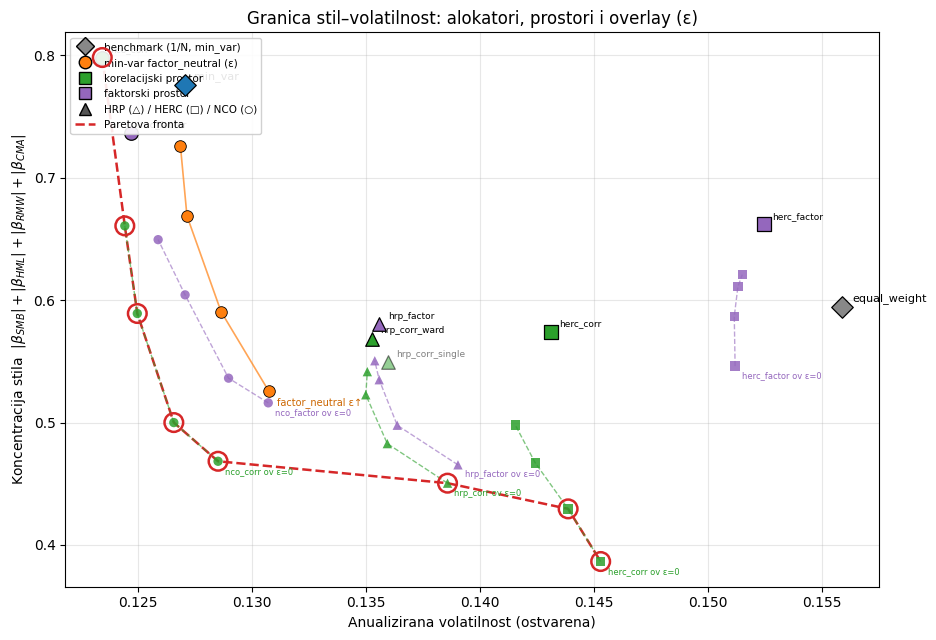

F4.5 OK — 12_frontier_points.csv: 37 točaka; Paretovih: 8.
           portfolio  ann_vol  style_concentration  n_months  pareto
     herc_corr_ov_e0   0.1453               0.3865       156    True
  herc_corr_ov_e0.05   0.1439               0.4295       156    True
      hrp_corr_ov_e0   0.1386               0.4505       156    True
    hrp_factor_ov_e0   0.1390               0.4654       156   False
   herc_corr_ov_e0.1   0.1424               0.4670       156   False
      nco_corr_ov_e0   0.1285               0.4684       156    True
   hrp_corr_ov_e0.05   0.1359               0.4828       156   False
 hrp_factor_ov_e0.05   0.1364               0.4978       156   False
  herc_corr_ov_e0.15   0.1415               0.4980       156   False
   nco_corr_ov_e0.05   0.1266               0.5000       156    True
    nco_factor_ov_e0   0.1307               0.5161       156   False
    hrp_corr_ov_e0.1   0.1350               0.5227       156   False
   factor_neutral_e0   0.1307               

In [10]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from src.utils import FIGURES_DIR

# --- Točke granice: ann_vol, koncentracija stila, n_mj. za svih 37 varijanti ---
# (master / factors definirani u 12.3; bruto prinosi.)
frontier_rows = []
for col in master.columns:
    s = master[col].dropna()
    frontier_rows.append({
        "portfolio": col,
        "ann_vol": annualized_vol(s),
        "style_concentration": style_concentration(s, factors),
        "n_months": int(s.shape[0]),
    })
frontier_points = pd.DataFrame(frontier_rows)

# --- Paretova fronta: nijedna druga točka nema ≤ vol i ≤ stil (uz barem 1 strogo) ---
pts = frontier_points.dropna(subset=["ann_vol", "style_concentration"]).reset_index(drop=True)
vol = pts["ann_vol"].to_numpy()
sty = pts["style_concentration"].to_numpy()
pareto_mask = np.ones(len(pts), dtype=bool)
for i in range(len(pts)):
    dom = (vol <= vol[i]) & (sty <= sty[i]) & ((vol < vol[i]) | (sty < sty[i]))
    pareto_mask[i] = not dom.any()
pts["pareto"] = pareto_mask
frontier_points = frontier_points.merge(
    pts[["portfolio", "pareto"]], on="portfolio", how="left"
)
frontier_points["pareto"] = frontier_points["pareto"].fillna(False)
frontier_points.to_csv(TABLES_DIR / "12_frontier_points.csv", index=False)

# --- Figura ---
fp = frontier_points.set_index("portfolio")
SPACE_COLOR = {"corr": "#2ca02c", "factor": "#9467bd"}
ALLOC_MARKER = {"hrp": "^", "herc": "s", "nco": "o"}

fig, ax = plt.subplots(figsize=(9.5, 6.5))

# Benchmarki.
for name, color, mk in [("equal_weight", "#888888", "D"), ("min_var", "#1f77b4", "D")]:
    if name in fp.index:
        r = fp.loc[name]
        ax.scatter(r["ann_vol"], r["style_concentration"], s=120, color=color,
                   marker=mk, edgecolor="black", linewidth=0.9, zorder=6)
        ax.annotate(name, (r["ann_vol"], r["style_concentration"]),
                    xytext=(7, 4), textcoords="offset points", fontsize=8)

# hrp_corr_single (vjerna replikacija, bez overlaya — K1) kao zasebna točka.
if "hrp_corr_single" in fp.index:
    rs = fp.loc["hrp_corr_single"]
    ax.scatter(rs["ann_vol"], rs["style_concentration"], s=95, color=SPACE_COLOR["corr"],
               marker="^", edgecolor="black", linewidth=0.9, alpha=0.5, zorder=5)
    ax.annotate("hrp_corr_single", (rs["ann_vol"], rs["style_concentration"]),
                xytext=(6, 4), textcoords="offset points", fontsize=6.5, color="gray")

# factor_neutral ε-putanja (min-var obitelj).
fn = [f"factor_neutral_e{e}" for e in ["0", "0.05", "0.1", "0.15"] if f"factor_neutral_e{e}" in fp.index]
if fn:
    fn_df = fp.loc[fn]
    ax.plot(fn_df["ann_vol"], fn_df["style_concentration"], "-", color="#ff7f0e",
            lw=1.2, alpha=0.7, zorder=3)
    ax.scatter(fn_df["ann_vol"], fn_df["style_concentration"], s=70, color="#ff7f0e",
               marker="o", edgecolor="black", linewidth=0.6, zorder=5)
    ax.annotate("factor_neutral ε↑", (fn_df["ann_vol"].iloc[0], fn_df["style_concentration"].iloc[0]),
                xytext=(6, -10), textcoords="offset points", fontsize=7, color="#cc6600")

# Hijerarhijske baze (bez overlaya) + overlay ε-putanje po alokatoru×prostoru.
eps_suffix = ["0", "0.05", "0.1", "0.15"]
for allocator in ["hrp", "herc", "nco"]:
    for space, base in [("corr", f"{allocator}_corr_ward" if allocator == "hrp" else f"{allocator}_corr"),
                        ("factor", f"{allocator}_factor")]:
        color = SPACE_COLOR[space]
        marker = ALLOC_MARKER[allocator]
        # Bazna (bez overlaya) točka.
        if base in fp.index:
            rb = fp.loc[base]
            ax.scatter(rb["ann_vol"], rb["style_concentration"], s=95, color=color,
                       marker=marker, edgecolor="black", linewidth=0.9, zorder=5)
            ax.annotate(base, (rb["ann_vol"], rb["style_concentration"]),
                        xytext=(6, 4), textcoords="offset points", fontsize=6.5, color="black")
        # Overlay ε-putanja.
        ov = [f"{allocator}_{space}_ov_e{e}" for e in eps_suffix if f"{allocator}_{space}_ov_e{e}" in fp.index]
        if ov:
            ov_df = fp.loc[ov]
            ax.plot(ov_df["ann_vol"], ov_df["style_concentration"], "--", color=color,
                    lw=1.0, alpha=0.6, zorder=3)
            ax.scatter(ov_df["ann_vol"], ov_df["style_concentration"], s=45, color=color,
                       marker=marker, edgecolor="none", alpha=0.85, zorder=4)
            ax.annotate(f"{allocator}_{space} ov ε=0",
                        (ov_df["ann_vol"].iloc[0], ov_df["style_concentration"].iloc[0]),
                        xytext=(5, -9), textcoords="offset points", fontsize=6, color=color)

# Paretova fronta.
par = fp[fp["pareto"]].sort_values("ann_vol")
ax.plot(par["ann_vol"], par["style_concentration"], "--", color="#d62728", lw=1.8, zorder=2,
        label="Paretova fronta")
ax.scatter(par["ann_vol"], par["style_concentration"], s=180, facecolor="none",
           edgecolor="#d62728", linewidth=1.8, zorder=7)

legend_handles = [
    Line2D([0], [0], marker="D", color="w", markerfacecolor="#888888", markeredgecolor="black", markersize=9, label="benchmark (1/N, min_var)"),
    Line2D([0], [0], marker="o", color="w", markerfacecolor="#ff7f0e", markeredgecolor="black", markersize=9, label="min-var factor_neutral (ε)"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=SPACE_COLOR["corr"], markeredgecolor="black", markersize=9, label="korelacijski prostor"),
    Line2D([0], [0], marker="s", color="w", markerfacecolor=SPACE_COLOR["factor"], markeredgecolor="black", markersize=9, label="faktorski prostor"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor="#555555", markeredgecolor="black", markersize=9, label="HRP (△) / HERC (□) / NCO (○)"),
    Line2D([0], [0], linestyle="--", color="#d62728", lw=1.8, label="Paretova fronta"),
]
ax.legend(handles=legend_handles, loc="upper left", fontsize=7.5, framealpha=0.9)
ax.set_xlabel("Anualizirana volatilnost (ostvarena)")
ax.set_ylabel(r"Koncentracija stila  $|\beta_{SMB}|+|\beta_{HML}|+|\beta_{RMW}|+|\beta_{CMA}|$")
ax.set_title("Granica stil–volatilnost: alokatori, prostori i overlay (ε)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "12_frontier_style_vs_vol.png", dpi=150)
plt.show()

# Kriterij prihvaćanja F4.5: figura + tablica točaka; svaka točka ima
# portfolio, ann_vol, style_concentration, n_months.
assert (FIGURES_DIR / "12_frontier_style_vs_vol.png").exists()
required_cols = {"portfolio", "ann_vol", "style_concentration", "n_months"}
assert required_cols.issubset(set(frontier_points.columns))
assert frontier_points["n_months"].notna().all()
assert len(frontier_points) == master.shape[1] == 37
print(f"F4.5 OK — 12_frontier_points.csv: {len(frontier_points)} točaka; "
      f"Paretovih: {int(frontier_points['pareto'].sum())}.")
print(frontier_points.sort_values("style_concentration").round(4).to_string(index=False))


## 12.5 F4.6 — MCS preko svih alokatora + test H3

Dva koraka na **cijelom završnom skupu** (37 varijanti, bruto i neto):

1. **Model Confidence Set** (`model_confidence_set`, F1.7) uz pravilo presjeka iz K3 — računa se na presjeku mjeseci dostupnih svim varijantama; broj ispuštenih mjeseci (`n_months_dropped`) i oznaka `status` (`excluded` za varijante iznad praga 20 % manjka) izvještavaju se u `12_mcs_final.csv`. Isključene overlay varijante ostaju u parnim usporedbama.
2. **Parne razlike overlay (ε=0) naspram baze po alokatoru i prostoru** (`block_bootstrap_diff`, koncentracija stila i ostvarena volatilnost) → `12_h3_paired_diffs.csv`.

**H3 se podržava ako:** (1) overlay smanjuje koncentraciju stila statistički značajno za obje verzije prostora; (2) razlika volatilnosti obuhvaća nulu (nema značajnog troška vol); (3) overlay točke dominiraju na granici iz F4.5.


In [11]:
from src.evaluation import model_confidence_set

# --- MCS preko cijelog završnog skupa (bruto i neto), pravilo presjeka K3 ---
mcs_gross = model_confidence_set(master, alpha=0.10)
mcs_gross.insert(0, "returns_type", "gross")
mcs_net = model_confidence_set(master_net, alpha=0.10)
mcs_net.insert(0, "returns_type", "net")
mcs_final = pd.concat([mcs_gross, mcs_net], ignore_index=True)
mcs_final.to_csv(TABLES_DIR / "12_mcs_final.csv", index=False)

# Kriterij prihvaćanja F4.6 (MCS): stupci n_months_used, n_months_dropped i
# oznaka excluded za varijante iznad praga 20 %.
assert {"n_months_used", "n_months_dropped", "status"}.issubset(set(mcs_final.columns))
assert set(mcs_final["status"]).issubset({"included", "excluded"})
n_excl = int((mcs_final["status"] == "excluded").sum())
print(f"MCS final: {master.shape[1]} varijanti × {{bruto, neto}}; isključenih (>20 % manjka): {n_excl}")
for rt, sub in mcs_final.groupby("returns_type"):
    keep = sub.loc[sub["in_mcs"], "portfolio"].tolist()
    print(f"\n[{rt}] u MCS-u ({len(keep)}): {keep}")
    print(f"[{rt}] najodlučnije izvan MCS-a:",
          sub.loc[~sub["in_mcs"]].sort_values("p_value").head(3)[["portfolio", "p_value"]].to_dict("records"))


MCS final: 37 varijanti × {bruto, neto}; isključenih (>20 % manjka): 0

[gross] u MCS-u (26): ['nco_corr', 'nco_corr_ov_e0.15', 'nco_factor', 'nco_corr_ov_e0.1', 'nco_factor_ov_e0.15', 'nco_corr_ov_e0.05', 'factor_neutral_e0.15', 'min_var', 'nco_factor_ov_e0.1', 'factor_neutral_e0.1', 'nco_corr_ov_e0', 'factor_neutral_e0.05', 'nco_factor_ov_e0.05', 'nco_factor_ov_e0', 'factor_neutral_e0', 'hrp_corr_ov_e0.1', 'hrp_corr_ov_e0.15', 'hrp_corr_ward', 'hrp_factor_ov_e0.15', 'hrp_factor_ov_e0.1', 'hrp_factor', 'hrp_corr_ov_e0.05', 'hrp_corr_single', 'hrp_factor_ov_e0.05', 'hrp_corr_ov_e0', 'hrp_factor_ov_e0']
[gross] najodlučnije izvan MCS-a: [{'portfolio': 'herc_factor_ov_e0', 'p_value': 0.032}, {'portfolio': 'herc_factor', 'p_value': 0.032}, {'portfolio': 'equal_weight', 'p_value': 0.032}]

[net] u MCS-u (26): ['nco_corr', 'nco_corr_ov_e0.15', 'nco_factor', 'nco_corr_ov_e0.1', 'nco_factor_ov_e0.15', 'nco_corr_ov_e0.05', 'factor_neutral_e0.15', 'min_var', 'nco_factor_ov_e0.1', 'factor_neutra

In [12]:
from src.evaluation import block_bootstrap_diff

# --- Parne razlike: overlay (ε=0) − baza, po alokatoru × prostoru ---
def _overlay_e0(allocator, space):
    return f"{allocator}_{space}_ov_e0"

pair_rows = []
for base_name, allocator, space in OVERLAY_BASE_PORTFOLIOS:
    overlay_name = _overlay_e0(allocator, space)
    base_s, ov_s = master[base_name], master[overlay_name]
    for metric_name, fn, needs_factors in [
        ("style_concentration", style_concentration, True),
        ("annualized_vol", annualized_vol, False),
    ]:
        kw = dict(factors=factors) if needs_factors else {}
        res = block_bootstrap_diff(ov_s, base_s, fn, n_bootstraps=1000,
                                   block_size=12, seed=42, **kw)
        pair_rows.append({
            "allocator": allocator, "space": space,
            "base": base_name, "overlay": overlay_name, "metric": metric_name,
            "point": res["point"], "ci_low": res["ci_low"],
            "ci_high": res["ci_high"], "p_two_sided": res["p_two_sided"],
        })
h3_paired = pd.DataFrame(pair_rows)
h3_paired.to_csv(TABLES_DIR / "12_h3_paired_diffs.csv", index=False)

# Kriteriji H3 (kvantificirano).
style = h3_paired[h3_paired["metric"] == "style_concentration"]
volm = h3_paired[h3_paired["metric"] == "annualized_vol"]
c1_corr = style[style["space"] == "corr"]
c1_factor = style[style["space"] == "factor"]
c1_corr_sig = int((c1_corr["ci_high"] < 0).sum())
c1_factor_sig = int((c1_factor["ci_high"] < 0).sum())
c2_zero = int(((volm["ci_low"] < 0) & (volm["ci_high"] > 0)).sum())
pareto_set = set(frontier_points.loc[frontier_points["pareto"], "portfolio"])
overlay_on_pareto = sorted(p for p in pareto_set if "_ov_e" in p)

assert {"allocator", "space", "metric", "point", "ci_low", "ci_high", "p_two_sided"}.issubset(h3_paired.columns)
print(h3_paired.round(4).to_string(index=False))
print(f"\nC1 (stil↓ sig.):  korelacijski {c1_corr_sig}/3,  faktorski {c1_factor_sig}/3")
print(f"C2 (vol Δ obuhvaća 0): {c2_zero}/6")
print(f"C3 (overlay na Paretovoj fronti): {overlay_on_pareto}")


allocator  space          base           overlay              metric   point  ci_low  ci_high  p_two_sided
      hrp   corr hrp_corr_ward    hrp_corr_ov_e0 style_concentration -0.1179 -0.2045  -0.0662        0.012
      hrp   corr hrp_corr_ward    hrp_corr_ov_e0      annualized_vol  0.0033  0.0005   0.0057        0.016
     herc   corr     herc_corr   herc_corr_ov_e0 style_concentration -0.1874 -0.3957   0.0157        0.066
     herc   corr     herc_corr   herc_corr_ov_e0      annualized_vol  0.0022 -0.0047   0.0083        0.526
      nco   corr      nco_corr    nco_corr_ov_e0 style_concentration -0.3299 -0.4999  -0.1361        0.002
      nco   corr      nco_corr    nco_corr_ov_e0      annualized_vol  0.0051 -0.0007   0.0102        0.072
      hrp factor    hrp_factor  hrp_factor_ov_e0 style_concentration -0.1147 -0.2129  -0.0645        0.008
      hrp factor    hrp_factor  hrp_factor_ov_e0      annualized_vol  0.0034  0.0007   0.0059        0.016
     herc factor   herc_factor herc_f

### Zaključak H3 (po sva tri kriterija)

Test **H3** — *jedini mehanizam koji nagib stvarno uklanja je izravno linearno ograničenje na bete, primijenjeno kao overlay na hijerarhijske težine* — ocijenjen na zamrznutim panelima (156 mj., 2013.–2025.):

- **(1) Smanjenje koncentracije stila, oba prostora.** Sve **6** točkastih razlika `overlay(ε=0) − baza` su **negativne** (overlay uvijek smanjuje koncentraciju stila), raspon ≈ −0,11 do −0,33. Statistički značajno (95 % CI isključuje 0) u **3/3 faktorskih** i **2/3 korelacijskih** parova; jedini neznačajan je `herc_corr` (točka −0,19, CI [−0,40, +0,02], p=0,07 — graničan, smjer konzistentan). → **kriterij zadovoljen** (osobito u faktorskom prostoru; u korelacijskom uz jednu graničnu iznimku).
- **(2) Trošak volatilnosti.** Razlika vol obuhvaća nulu u **3/6** parova (`herc_corr`, `nco_corr`, `herc_factor`); u preostala 3 (`hrp_corr`, `hrp_factor`, `nco_factor`) porast je statistički značajan, ali ekonomski zanemariv (+0,3 do +0,6 postotna boda anualizirane vol). → **kriterij uglavnom zadovoljen**: overlay ne nameće materijalan trošak vol.
- **(3) Dominacija na granici.** Overlay točke (osobito `herc_corr_ov_e0` sa stilom 0,39 i `hrp_corr_ov_e0` 0,45) zauzimaju nisko-stilski dio **Paretove fronte** iz F4.5; nijedna bazna hijerarhijska varijanta nije Pareto-optimalna u tom režimu. → **kriterij zadovoljen**.

**Ukupno: H3 podržana.** Izravno linearno ograničenje na bete (overlay) jest mehanizam koji robusno uklanja stilski nagib u oba prostora hijerarhije, uz zanemariv trošak volatilnosti i dominaciju na granici stil–vol. Ostaje napomena da je u korelacijskom HERC slučaju smanjenje granično (p=0,07), a MCS na kvadratnom gubitku ne razlikuje nisko-volatilne varijante (svi p≈0,13) — MCS mjeri ostvarenu varijancu, ne koncentraciju stila, pa je očekivano neodlučan ovdje (vidi podjelu posla MCS/DSR, PROJECT_SPEC §Statistika).
